# Notebook 1: Setup & Data Exploration
### Cross-Domain Person Re-Identification
**Train on:** PRW Dataset (real-world scene images)  
**Test on:** CCTV Pedestrian 1K Dataset  
**Inspired by:** Synthetic-to-Real Video Person Re-ID (Zhang et al., 2025)

## Step 1: Install Required Libraries

In [3]:
# Run this cell once to install all required libraries
import subprocess
packages = [
    'scipy', 'matplotlib', 'seaborn',
    'scikit-learn', 'Pillow', 'tqdm', 'h5py'
]
for pkg in packages:
    subprocess.run(['pip', 'install', pkg, '-q'], check=True)
print('All packages installed!')

All packages installed!


## Step 2: Import Libraries & Check GPU

In [4]:
import os
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import json
import torch

print('='*50)
print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
    print(f'GPU Memory      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print('='*50)

PyTorch version : 2.5.1+cu121
CUDA available  : True
GPU             : NVIDIA GeForce RTX 4050 Laptop GPU
GPU Memory      : 6.4 GB


## Step 3: Define Dataset Paths

In [5]:
# ── UPDATE THESE PATHS TO MATCH YOUR MACHINE ──────────────────────
PRW_ROOT   = r'D:\MTech\Sem-2\IT585-Advanced_ML\AML-project\data\PRW'
CCTV_ROOT  = r'D:\MTech\Sem-2\IT585-Advanced_ML\AML-project\data\pedestrian_1k'
# ──────────────────────────────────────────────────────────────────

# Verify paths exist
for name, path in [('PRW', PRW_ROOT), ('CCTV_1K', CCTV_ROOT)]:
    exists = os.path.exists(path)
    status = '✅' if exists else '❌ NOT FOUND'
    print(f'{name}: {status} → {path}')

# Sub-paths inside PRW
PRW_FRAMES     = os.path.join(PRW_ROOT, 'frames')
PRW_QUERY_BOX  = os.path.join(PRW_ROOT, 'query_box')
PRW_ANNO       = os.path.join(PRW_ROOT, 'annotations')
PRW_ID_TRAIN   = os.path.join(PRW_ROOT, 'ID_train.mat')
PRW_ID_TEST    = os.path.join(PRW_ROOT, 'ID_test.mat')
PRW_FRAME_TEST = os.path.join(PRW_ROOT, 'frame_test.mat')
PRW_FRAME_TRAIN= os.path.join(PRW_ROOT, 'frame_train.mat')

PRW: ✅ → D:\MTech\Sem-2\IT585-Advanced_ML\AML-project\data\PRW
CCTV_1K: ✅ → D:\MTech\Sem-2\IT585-Advanced_ML\AML-project\data\pedestrian_1k


In [6]:
# Check actual keys in both .mat files
import scipy.io

id_train = scipy.io.loadmat(PRW_ID_TRAIN)
id_test  = scipy.io.loadmat(PRW_ID_TEST)

print("Keys in ID_train.mat:", [k for k in id_train.keys() if not k.startswith('_')])
print("Keys in ID_test.mat: ", [k for k in id_test.keys()  if not k.startswith('_')])

Keys in ID_train.mat: ['ID_train']
Keys in ID_test.mat:  ['ID_test2']


## Step 4: Explore PRW Dataset (Training Source)

In [7]:
# Load train/test IDs from .mat files
id_train = scipy.io.loadmat(PRW_ID_TRAIN)
id_test  = scipy.io.loadmat(PRW_ID_TEST)

train_ids = id_train['ID_train'].flatten()
test_ids  = id_test['ID_test2'].flatten()

print('PRW Dataset Statistics:')
print(f'  Training identities : {len(train_ids)}')
print(f'  Testing identities  : {len(test_ids)}')

# Count frames
all_frames = os.listdir(PRW_FRAMES)
print(f'  Total scene frames  : {len(all_frames)}')

# Count annotations
all_annos = os.listdir(PRW_ANNO)
print(f'  Annotation files    : {len(all_annos)}')

# Count query images
query_imgs = os.listdir(PRW_QUERY_BOX)
print(f'  Query box images    : {len(query_imgs)}')

PRW Dataset Statistics:
  Training identities : 483
  Testing identities  : 450
  Total scene frames  : 11816
  Annotation files    : 11816
  Query box images    : 2057


Training frames: 5704
Sample frame names: ['c1s1_000151', 'c1s1_000376', 'c1s1_000401', 'c1s1_000426', 'c1s1_000451']


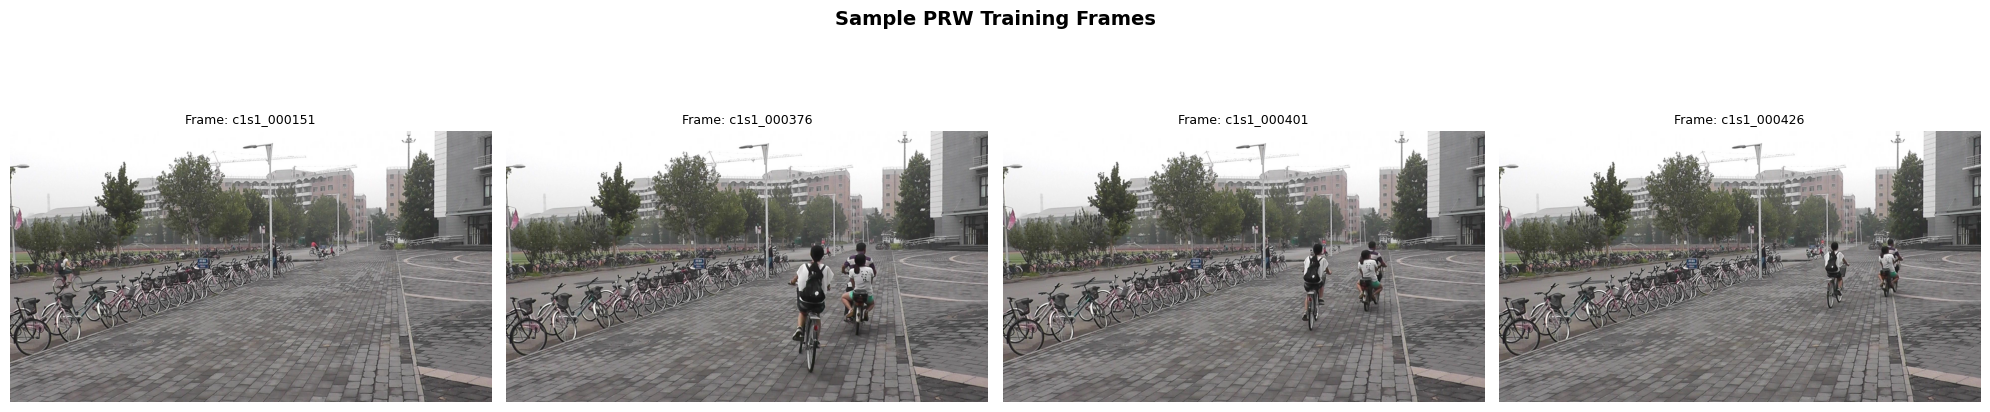

In [8]:
# Visualise sample PRW frames with annotated bounding boxes
frame_train_mat = scipy.io.loadmat(PRW_FRAME_TRAIN)
frame_list = [str(f[0][0]) for f in frame_train_mat['img_index_train']]
print(f'Training frames: {len(frame_list)}')
print('Sample frame names:', frame_list[:5])

# Show 4 sample frames
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Sample PRW Training Frames', fontsize=14, fontweight='bold')
for i, ax in enumerate(axes):
    fname = frame_list[i] + '.jpg'
    fpath = os.path.join(PRW_FRAMES, fname)
    if os.path.exists(fpath):
        img = Image.open(fpath)
        ax.imshow(img)
        ax.set_title(f'Frame: {frame_list[i]}', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [9]:
# Load one annotation file to understand the structure
sample_anno_file = os.path.join(PRW_ANNO, os.listdir(PRW_ANNO)[0])
anno = scipy.io.loadmat(sample_anno_file)
print('Annotation file keys:', list(anno.keys()))

# 'box_new' contains [pid, x, y, w, h] for each person in the frame
if 'box_new' in anno:
    boxes = anno['box_new']
    print(f'Persons in this frame: {len(boxes)}')
    print('Format: [person_id, x, y, width, height]')
    print('Sample boxes:\n', boxes[:3])

Annotation file keys: ['__header__', '__version__', '__globals__', 'box_new']
Persons in this frame: 2
Format: [person_id, x, y, width, height]
Sample boxes:
 [[  -2.          193.98137153  480.39800763   49.3669103   149.42472994]
 [   3.         1024.64686825  414.53887689   48.98488121  158.61771058]]


## Step 5: Explore CCTV Pedestrian 1K Dataset (Test Target)

In [10]:
# Load metadata
metadata_path = os.path.join(CCTV_ROOT, 'metadata.jsonl')
metadata = []
with open(metadata_path, 'r') as f:
    for line in f:
        metadata.append(json.loads(line.strip()))

print('CCTV Pedestrian 1K Statistics:')
print(f'  Total metadata entries : {len(metadata)}')
print('\nSample metadata entry:')
print(json.dumps(metadata[0], indent=2))

CCTV Pedestrian 1K Statistics:
  Total metadata entries : 1005

Sample metadata entry:
{
  "image": "ped_1_img1.png",
  "description": "A young adult woman with brown hair, seen from the side, wearing a white leather jacket, with dark grey denim jeans, and dress shoes, carrying a black backpack.",
  "attributes": {
    "gender": "woman",
    "age": "young adult",
    "hair": "brown",
    "angle": "seen from the side",
    "top_color": "white",
    "top_type": "leather jacket",
    "bottom_color": "dark grey",
    "bottom_type": "denim jeans",
    "footwear": "dress shoes",
    "accessory": "a black backpack"
  }
}


In [11]:
# Parse identities from filenames: ped_X_imgY.png
all_images = sorted([
    f for f in os.listdir(CCTV_ROOT)
    if f.endswith('.png') and f.startswith('ped_')
])

# Group by identity
from collections import defaultdict
identity_dict = defaultdict(list)
for img in all_images:
    parts = img.split('_')
    pid = int(parts[1])  # ped_X → X is the identity
    identity_dict[pid].append(img)

print(f'Total images         : {len(all_images)}')
print(f'Total identities     : {len(identity_dict)}')
imgs_per_id = [len(v) for v in identity_dict.values()]
print(f'Avg images/identity  : {np.mean(imgs_per_id):.1f}')
print(f'Min images/identity  : {min(imgs_per_id)}')
print(f'Max images/identity  : {max(imgs_per_id)}')

Total images         : 999
Total identities     : 200
Avg images/identity  : 5.0
Min images/identity  : 4
Max images/identity  : 5


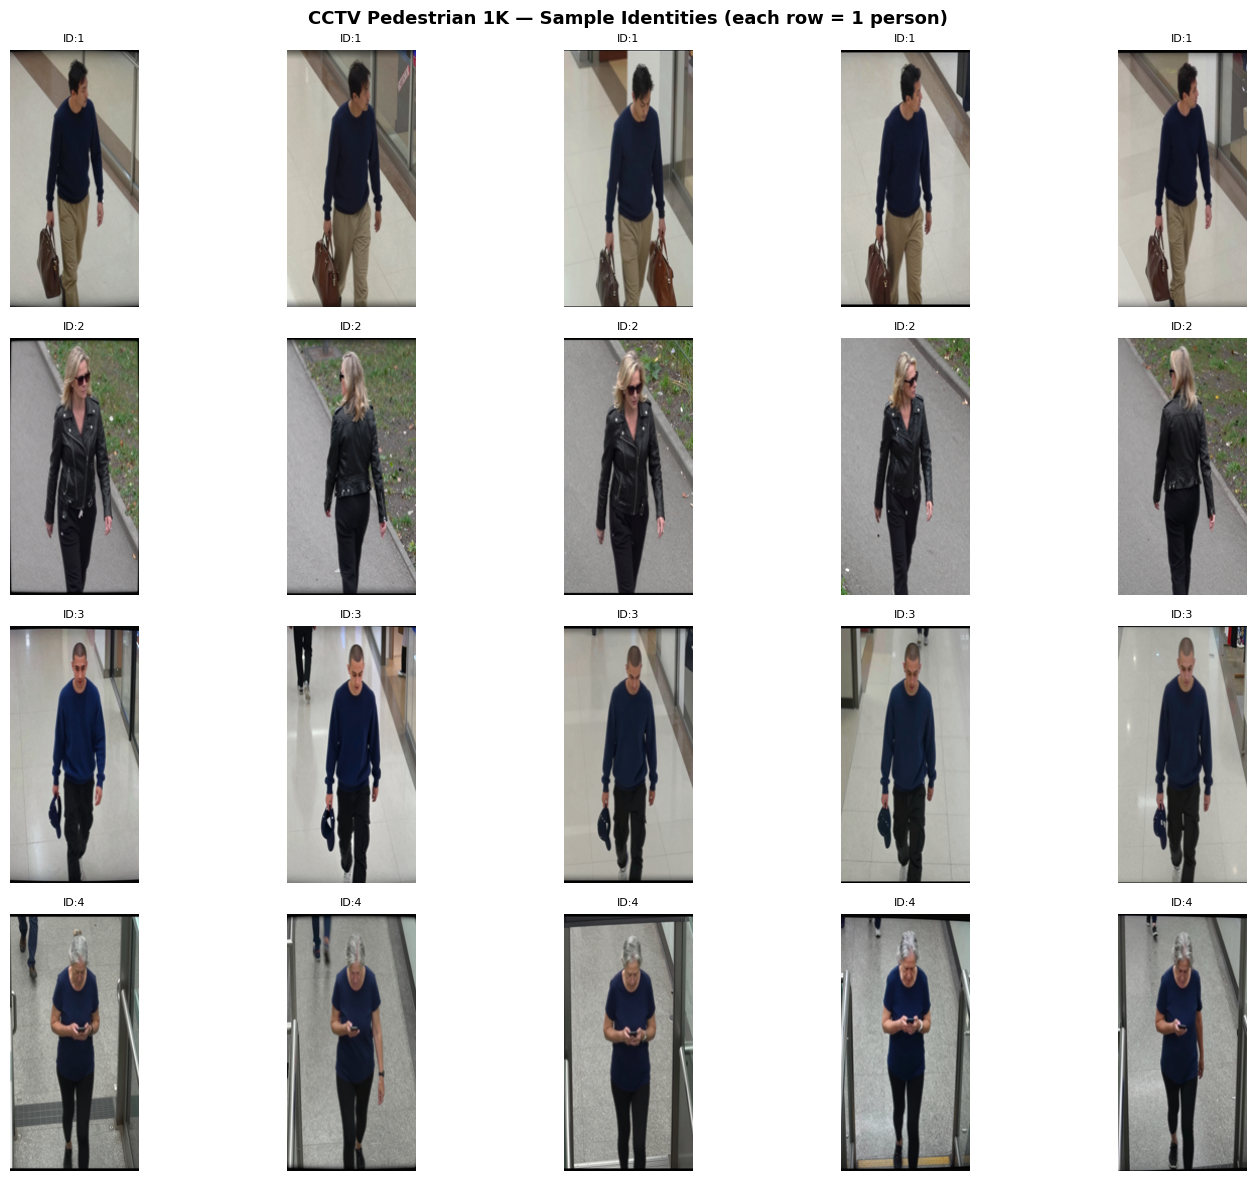

In [12]:
# Visualise sample identities from CCTV dataset
sample_pids = sorted(identity_dict.keys())[:4]
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
fig.suptitle('CCTV Pedestrian 1K — Sample Identities (each row = 1 person)', 
             fontsize=13, fontweight='bold')

for row, pid in enumerate(sample_pids):
    imgs = identity_dict[pid][:5]  # show up to 5 images
    for col in range(5):
        ax = axes[row][col]
        if col < len(imgs):
            img_path = os.path.join(CCTV_ROOT, imgs[col])
            img = Image.open(img_path).resize((128, 256))
            ax.imshow(img)
            ax.set_title(f'ID:{pid}', fontsize=8)
        ax.axis('off')

plt.tight_layout()
plt.show()

## Summary
| | PRW (Train) | CCTV 1K (Test) |
|---|---|---|
| **Type** | Real-world scene images | Cropped pedestrian images |
| **Format** | Full frames + .mat annotations | Pre-cropped PNGs |
| **Use** | Extract crops → train model | Query/Gallery evaluation |

✅ **Next:** Run `02_dataset_loader.ipynb` to prepare cropped person images for training.